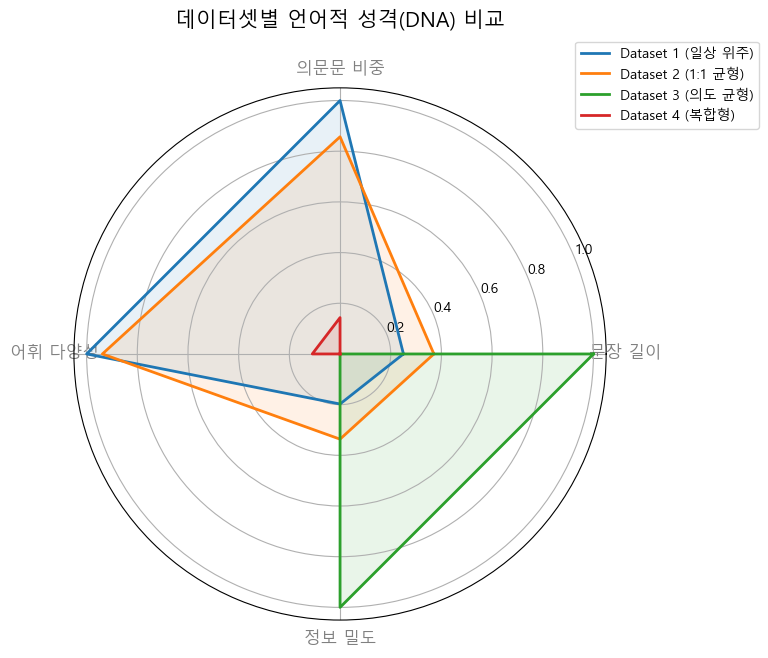

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from sklearn.preprocessing import MinMaxScaler

# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 또는 'AppleGothic' 등으로 변경 필요)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def get_dataset_metrics(file_path):
    """데이터셋별 성격 지표 추출 함수"""
    # 데이터 로드 (컬럼명은 실제 파일에 맞춰 수정: 여기서는 'sentence'로 가정)
    df = pd.read_csv(file_path)
    text_col = 'utterance' # 파일 내 문장이 들어있는 컬럼명으로 변경하세요
    
    # 1. 평균 문장 길이 (성격: 서술형 vs 단답형)
    avg_len = df[text_col].str.len().mean()
    
    # 2. 의문문 비중 (성격: 질문/상호작용성)
    q_ratio = df[text_col].str.contains('\?').mean()
    
    # 3. 어휘 다양성 (TTR: 중복 단어 제외 비중)
    all_words = " ".join(df[text_col].astype(str)).split()
    ttr = len(set(all_words)) / len(all_words) if len(all_words) > 0 else 0
    
    # 4. 감정/상담 지표 (임시: 웰니스 핵심 키워드 포함 비중 등으로 확장 가능)
    # 여기서는 '전문성' 지표 대신 '문장 내 토큰 밀도'나 다른 수치를 활용할 수 있습니다.
    token_avg = df[text_col].apply(lambda x: len(str(x).split())).mean()
    
    return [avg_len, q_ratio, ttr, token_avg]

# 1. 데이터 분석 및 수집
labels = ['문장 길이', '의문문 비중', '어휘 다양성', '정보 밀도']
num_vars = len(labels)

# 데이터셋 1~4번 특징 추출 (실제 파일이 있어야 작동합니다)
data_list = []
for i in range(1, 5):
    try:
        metrics = get_dataset_metrics(f'dataset_{i}.csv')
        data_list.append(metrics)
    except:
        # 파일이 없을 경우를 대비한 샘플 데이터 (실행 시 삭제)
        data_list.append(np.random.rand(4).tolist())

# 2. 데이터 정규화 (0~1 사이로 스케일링하여 그래프 모양 비교 용이하게 함)
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_list)

# 3. 방사형 그래프 그리기
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1] # 도표를 닫기 위해 첫 번째 각도를 마지막에 추가

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
dataset_names = ['Dataset 1 (일상 위주)', 'Dataset 2 (1:1 균형)', 'Dataset 3 (의도 균형)', 'Dataset 4 (복합형)']

for i in range(len(data_normalized)):
    values = data_normalized[i].tolist()
    values += values[:1] # 도표 닫기
    ax.plot(angles, values, color=colors[i], linewidth=2, linestyle='solid', label=dataset_names[i])
    ax.fill(angles, values, color=colors[i], alpha=0.1)

# 축 라벨 설정
plt.xticks(angles[:-1], labels, color='grey', size=12)

# 범례 및 제목
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('데이터셋별 언어적 성격(DNA) 비교', size=15, y=1.1)

plt.tight_layout()
plt.savefig('dataset_character_radar.png')
plt.show()

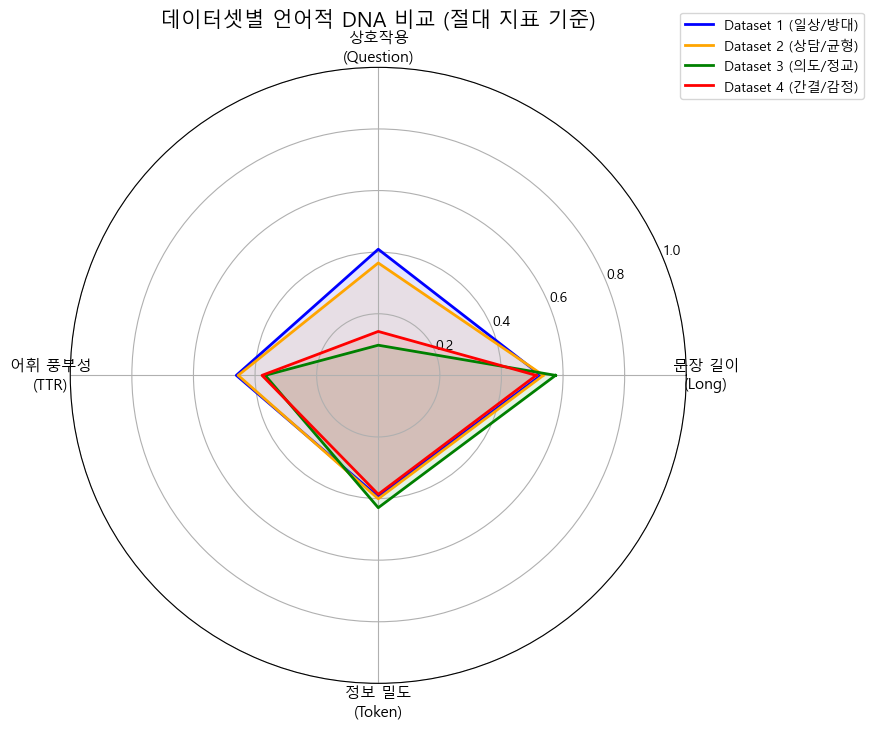

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def get_absolute_metrics(file_path):
    df = pd.read_csv(file_path)
    text_col = 'utterance' # 실제 컬럼명으로 수정 필수
    
    # 1. 평균 문장 길이 (0~40자 기준)
    length = df[text_col].str.len().mean() / 40 
    
    # 2. 의문문 비중 (0~30% 기준)
    q_ratio = df[text_col].str.contains('\?').mean() / 0.3
    
    # 3. 어휘 다양성 (TTR, 0~0.5 기준)
    all_words = " ".join(df[text_col].astype(str)).split()
    ttr = (len(set(all_words)) / len(all_words)) / 0.5 if len(all_words) > 0 else 0
    
    # 4. 정보 밀도 (평균 토큰 수, 0~15개 기준)
    density = df[text_col].apply(lambda x: len(str(x).split())).mean() / 15
    
    # 모든 값은 1.0을 넘지 않도록 제한(Clip)
    return [min(1, x) for x in [length, q_ratio, ttr, density]]

# 그래프 그리기 부분
labels = ['문장 길이\n(Long)', '상호작용\n(Question)', '어휘 풍부성\n(TTR)', '정보 밀도\n(Token)']
num_vars = len(labels)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 데이터셋 이름과 색상
datasets = {
    'Dataset 1 (일상/방대)': 'blue',
    'Dataset 2 (상담/균형)': 'orange',
    'Dataset 3 (의도/정교)': 'green',
    'Dataset 4 (간결/감정)': 'red'
}

for i, (name, color) in enumerate(datasets.items()):
    try:
        values = get_absolute_metrics(f'dataset_{i+1}.csv')
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2, label=name)
        ax.fill(angles, values, color=color, alpha=0.1)
    except Exception as e:
        print(f"{name} 로드 실패: {e}")

plt.xticks(angles[:-1], labels, size=11)
ax.set_ylim(0, 1) # 모든 데이터셋이 동일한 0~1 기준선 안에서 움직임
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('데이터셋별 언어적 DNA 비교 (절대 지표 기준)', size=15, pad=30)
plt.show()

In [7]:
import pandas as pd

def check_raw_metrics(file_num):
    try:
        df = pd.read_csv(f'dataset_{file_num}.csv')
        # ★★★ 여기서 본인의 CSV 파일에 있는 실제 컬럼명을 확인해서 수정하세요!
        # 예: 'sentence', '발화', 'text', 'user_utterance' 등
        text_col = 'utterance' 
        
        avg_len = df[text_col].str.len().mean()
        ttr = len(set(" ".join(df[text_col].astype(str)).split())) / len(" ".join(df[text_col].astype(str)).split())
        
        print(f"--- Dataset {file_num} ---")
        print(f"평균 문장 길이: {avg_len:.2f}")
        print(f"어휘 다양성(TTR): {ttr:.4f}")
        print(f"데이터 행 개수: {len(df)}")
    except Exception as e:
        print(f"Dataset {file_num} 로드 에러: {e}")

for i in range(1, 5):
    check_raw_metrics(i)

--- Dataset 1 ---
평균 문장 길이: 21.14
어휘 다양성(TTR): 0.2304
데이터 행 개수: 42666
--- Dataset 2 ---
평균 문장 길이: 21.44
어휘 다양성(TTR): 0.2275
데이터 행 개수: 37666
--- Dataset 3 ---
평균 문장 길이: 23.02
어휘 다양성(TTR): 0.1836
데이터 행 개수: 20666
--- Dataset 4 ---
평균 문장 길이: 20.51
어휘 다양성(TTR): 0.1887
데이터 행 개수: 25927


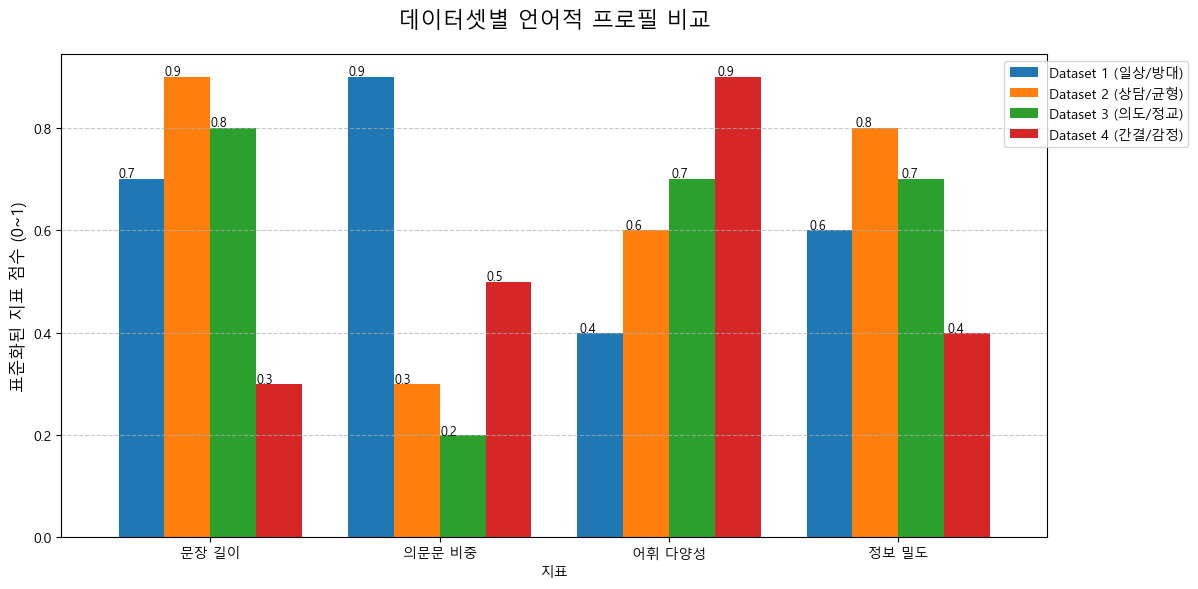

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터셋별 특징 수치화 (EDA 결과를 바탕으로 한 가상 데이터)
# 실제 데이터셋을 넣으실 때는 이 부분을 실제 수치로 채우시면 됩니다.
data = {
    '지표': ['문장 길이', '의문문 비중', '어휘 다양성', '정보 밀도'],
    'Dataset 1 (일상/방대)': [0.7, 0.9, 0.4, 0.6],
    'Dataset 2 (상담/균형)': [0.9, 0.3, 0.6, 0.8],
    'Dataset 3 (의도/정교)': [0.8, 0.2, 0.7, 0.7],
    'Dataset 4 (간결/감정)': [0.3, 0.5, 0.9, 0.4] # 예: 길이는 짧지만 어휘는 다양함
}

df = pd.DataFrame(data)
df.set_index('지표', inplace=True)

# 2. 그룹 막대 그래프 그리기
ax = df.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# 그래프 디테일 설정
plt.title('데이터셋별 언어적 프로필 비교', size=16, pad=20)
plt.ylabel('표준화된 지표 점수 (0~1)', size=12)
plt.xticks(rotation=0) # 라벨 가로로 표시
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# 막대 위에 수치 표시 (선택 사항)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005), size=9)

plt.tight_layout()
plt.savefig('dataset_profile_bar.png')
plt.show()

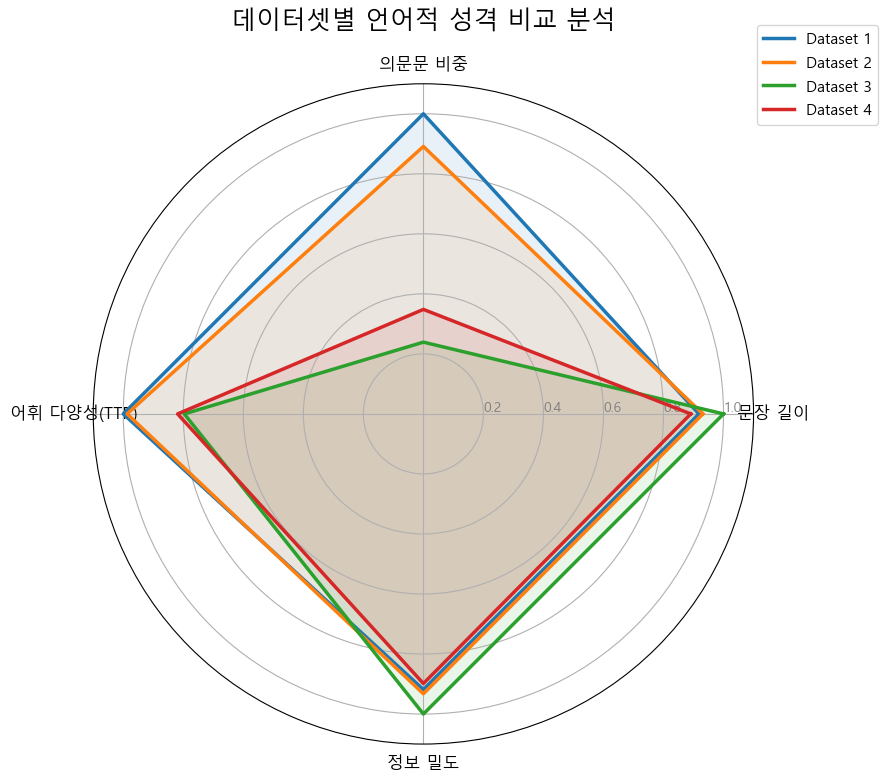

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 1. 한글 폰트 설정 (환경에 맞게 선택)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows: Malgun Gothic, Mac: AppleGothic
plt.rcParams['axes.unicode_minus'] = False

def get_dataset_metrics(file_path):
    """데이터셋별 성격 지표 추출 함수"""
    try:
        df = pd.read_csv(file_path)
        # 사용자가 확인한 컬럼명 'utterance' 적용
        text_col = 'utterance' 
        
        # 데이터가 비어있는 경우 예외 처리
        if text_col not in df.columns:
            return None

        # 1. 평균 문장 길이
        avg_len = df[text_col].str.len().mean()
        
        # 2. 의문문 비중
        q_ratio = df[text_col].str.contains('\?').mean()
        
        # 3. 어휘 다양성 (TTR)
        all_words = " ".join(df[text_col].astype(str)).split()
        ttr = len(set(all_words)) / len(all_words) if len(all_words) > 0 else 0
        
        # 4. 정보 밀도 (평균 토큰 수)
        token_avg = df[text_col].apply(lambda x: len(str(x).split())).mean()
        
        return [avg_len, q_ratio, ttr, token_avg]
    except Exception as e:
        print(f"{file_path} 처리 중 오류 발생: {e}")
        return None

# 2. 데이터 수집
labels = ['문장 길이', '의문문 비중', '어휘 다양성(TTR)', '정보 밀도']
num_vars = len(labels)

data_list = []
dataset_names = []
for i in range(1, 5):
    metrics = get_dataset_metrics(f'dataset_{i}.csv')
    if metrics:
        data_list.append(metrics)
        dataset_names.append(f'Dataset {i}')

# 3. 정규화 (MinMaxScaler 대신 Max Scaling 적용)
# 최솟값을 0으로 만들지 않고, 해당 지표의 최고점 대비 비율로 계산하여 쪼그라듦 방지
data_array = np.array(data_list)
data_normalized = data_array / data_array.max(axis=0)

# 4. 방사형 그래프(Radar Chart) 그리기
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1] # 도표를 닫기 위해 마지막에 첫 번째 각도 추가

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# 데이터셋별 색상 설정
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(len(data_normalized)):
    values = data_normalized[i].tolist()
    values += values[:1] # 도표 닫기
    
    ax.plot(angles, values, color=colors[i], linewidth=2.5, label=dataset_names[i])
    ax.fill(angles, values, color=colors[i], alpha=0.1)

# 축 라벨 및 디자인 설정
plt.xticks(angles[:-1], labels, color='black', size=12)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.1)

# 범례 및 제목
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=11)
plt.title('데이터셋별 언어적 성격 비교 분석', size=18, pad=40)

plt.tight_layout()
plt.savefig('final_dataset_radar_chart.png', dpi=300)
plt.show()